Notebook 03 — Data Cleaning

Step 1 — Missing Values Analysis

In [4]:
import pandas as pd
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

In [5]:
missing = df.isnull().sum()
missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": round(missing / len(df) * 100, 2)
})
missing_df.sort_values(by="Missing Count", ascending=False)

,Missing Count,Missing %
longitude,0,0.0
latitude,0,0.0
housing_median_age,0,0.0
total_rooms,0,0.0
total_bedrooms,0,0.0
population,0,0.0
households,0,0.0
median_income,0,0.0
median_house_value,0,0.0


Step 2 — Missing Values Visualisation

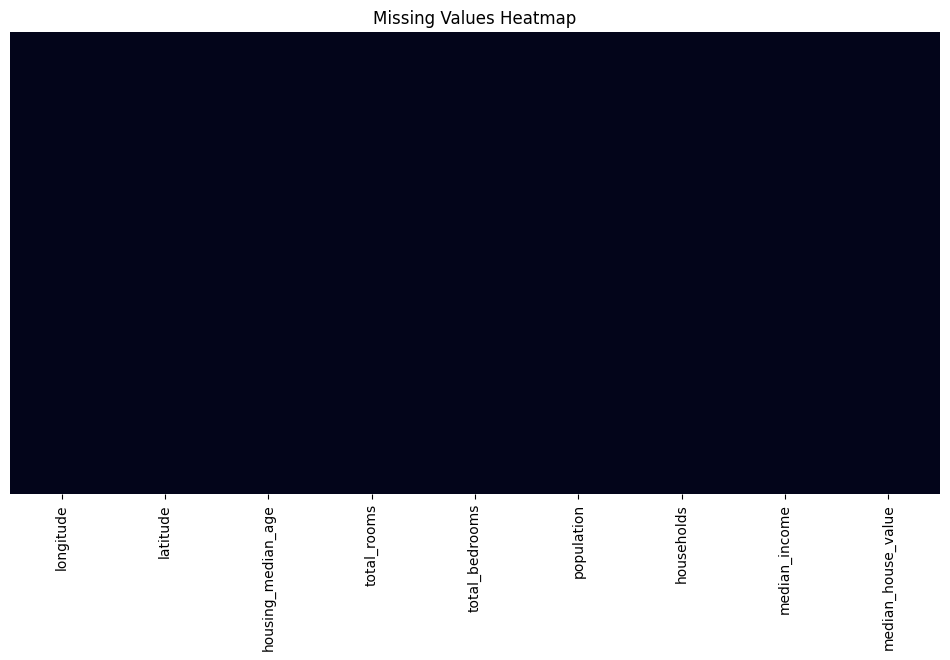

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

Step 3 — Handle Missing Values

Numerical Columns — Fill with Median

In [13]:
numeric_cols = df.select_dtypes(include=['number']).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

Categorical Columns — Fill with Mode

In [16]:
categorical_cols = df.select_dtypes(exclude=['number']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

Step 4 — Duplicate Records

In [18]:
print('Duplicates found:', df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicates found: 0


Step 5 — Outlier Detection

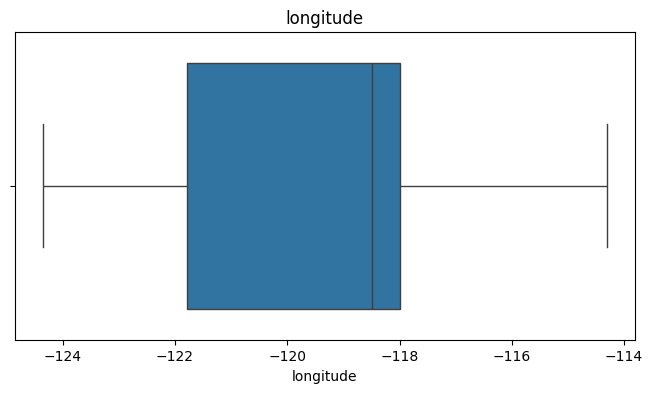

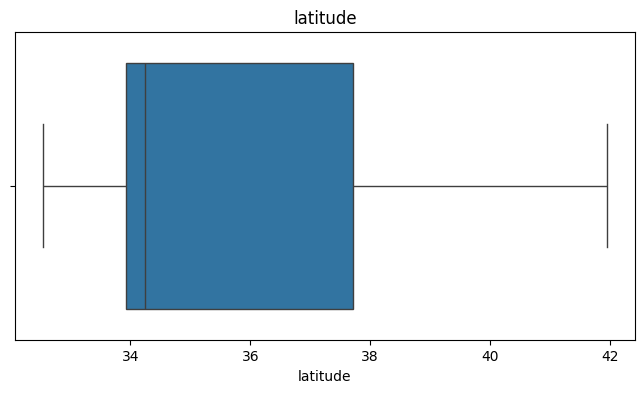

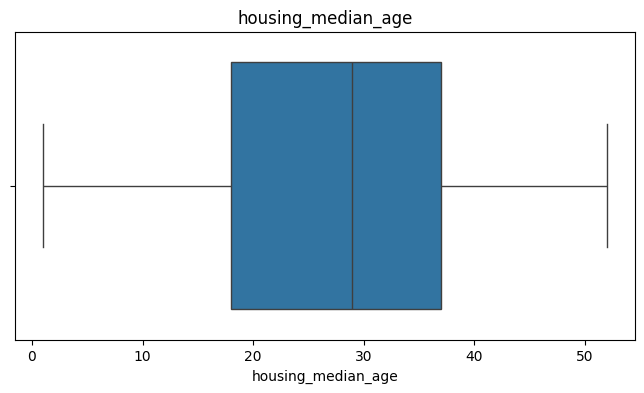

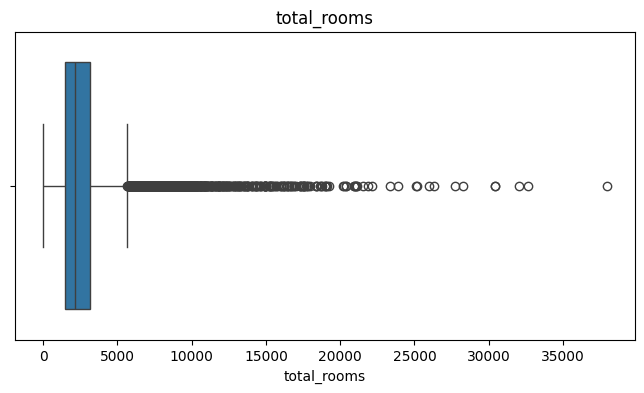

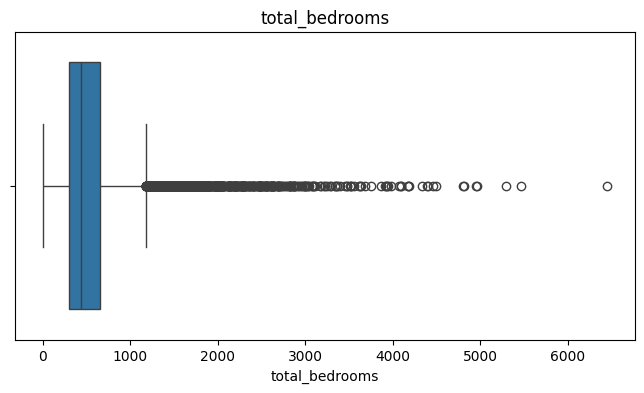

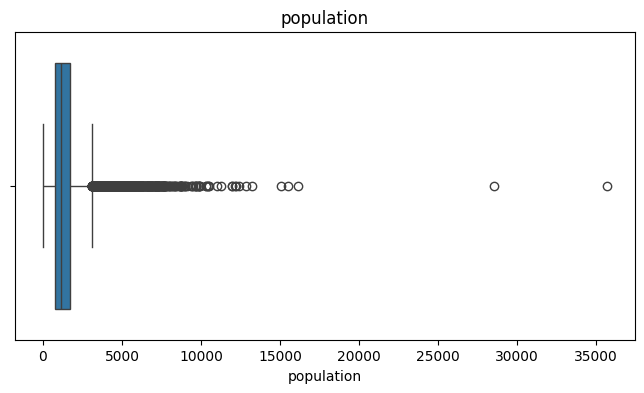

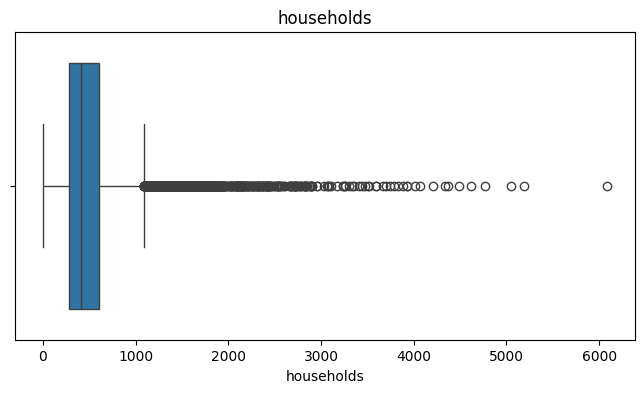

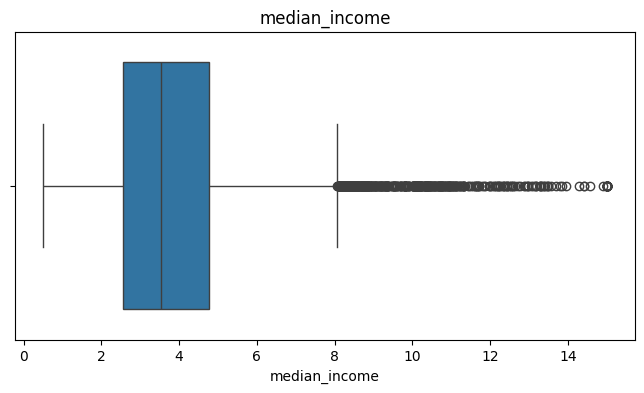

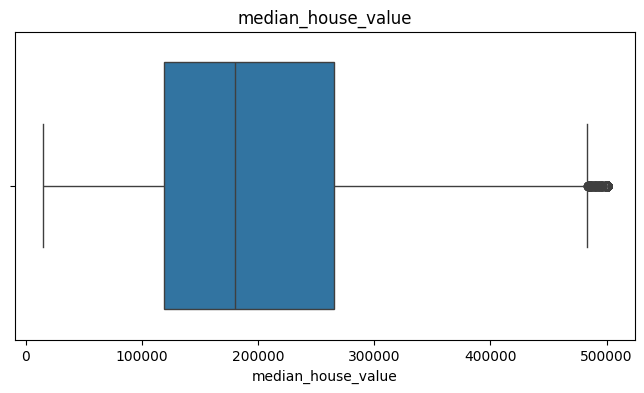

In [20]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Step 6 — Outlier Treatment (IQR Method)

In [23]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

Step 7 — Verify Cleaning

In [24]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 13181 entries, 2 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           13181 non-null  float64
 1   latitude            13181 non-null  float64
 2   housing_median_age  13181 non-null  float64
 3   total_rooms         13181 non-null  float64
 4   total_bedrooms      13181 non-null  float64
 5   population          13181 non-null  float64
 6   households          13181 non-null  float64
 7   median_income       13181 non-null  float64
 8   median_house_value  13181 non-null  float64
dtypes: float64(9)
memory usage: 1.0 MB


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


Step 8 — Save Cleaned Dataset

In [26]:
df.to_csv("cleaned_dataset.csv", index=False)